# Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))

# Enable autoreload for Jupyter notebooks
%load_ext autoreload
%autoreload 2

from paths import DATA_DATASETS, DATA_EMBEDDINGS, DATA_IMAGES
from helper_functions import verify_cluster_labels

Failed to read module file 'C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>",

# Load Data

In [2]:
outfits = pd.read_csv(DATA_DATASETS / "outfits.csv", sep=";")
embeddings = pd.read_csv(DATA_EMBEDDINGS / "embeddings_voyage_multimodal.csv", sep=";")
transactions = pd.read_csv(DATA_DATASETS / "transactions.csv", sep=";")

Join dataframes

In [3]:
data = outfits.merge(embeddings, left_on="id", right_on="outfit_id")

Get embedding-matrix from dataframe

In [4]:
embedding_cols = [col for col in data.columns if col.startswith("dim_")]
X = data[embedding_cols].values

Compute a 2D UMAP embedding of the high-dimensional feature matrix X for visualization.
The embedding is calculated once and reused to avoid repeated expensive computations.

In [5]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_2d = reducer_2d.fit_transform(X)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dimension reduction with UMAP to 20 dimensions to confirm that 2048 dimensions is too much to form robust clusters (Curse of dimensionality) with the K-Means algorithm. 

Initilize reducer 

In [6]:
reducer = umap.UMAP(
    n_components = 20, # reduce to 20 dimensions for clustering
    n_neighbors = 50,
    min_dist = 0.1,
    metric = "cosine",
    random_state = 42 # for reproducibility
)

X_reduced = reducer.fit_transform(X)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [7]:
kmeans = KMeans(n_clusters=8, random_state=42)

data["cluster"] = kmeans.fit_predict(X_reduced)

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_16344\1500716983.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["cluster"] = kmeans.fit_predict(X_reduced)


In [8]:
cluster_names = {   0: "Iconic Arm Candy", 
                    1: "Blouses & Shirts", 
                    2: "Dress", 
                    3: "Nordic Comfort", 
                    4: "Golden Hour Details", 
                    5: "Trousers", 
                    6: "Skirts", 
                    7: "Jackets & Coats" }

data["cluster_name"] = data["cluster"].map(cluster_names)

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_16344\655022086.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["cluster_name"] = data["cluster"].map(cluster_names)


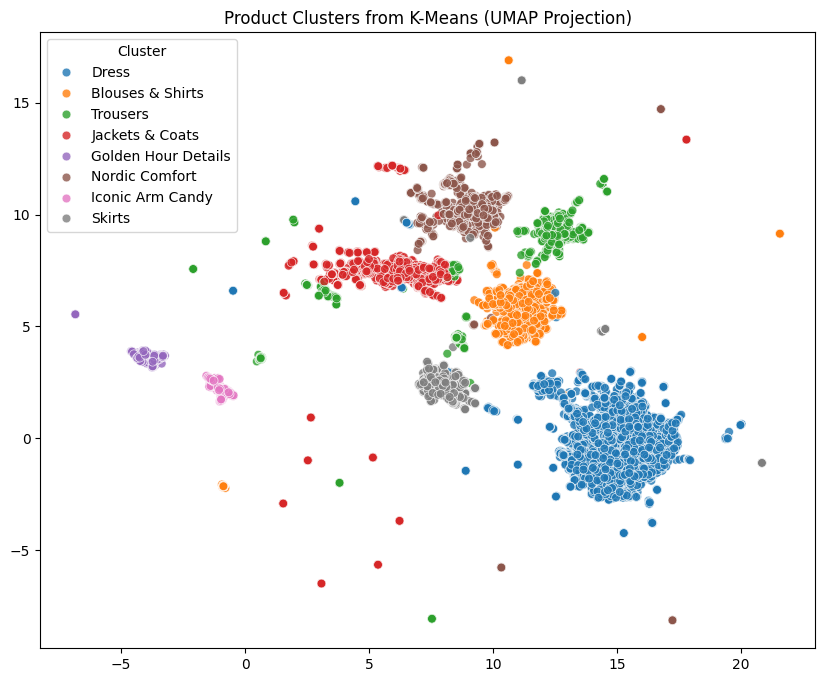

In [10]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=data["cluster_name"],
    palette="tab10",
    s=40,
    alpha=0.8
)

plt.title("Product Clusters from K-Means (UMAP Projection)")
plt.legend(title="Cluster")
plt.show()

# Business Profiling

## Retail price
Price the rental company has to buy the clothes at

In [11]:
price_profile = data.groupby("cluster")["retailPrice"].agg([
    "mean", "median", "min", "max", "count"
]).sort_values("mean", ascending=False)

price_profile.round(2) # Prices are in NOK - 1000 NOK ~ 80 CHF ~ 90 Euro

,mean,median,min,max,count
cluster,,,,,
0,6804.81,4000.0,0.0,52800.0,353
7,3937.86,3200.0,0.0,45000.0,1827
2,2801.97,2400.0,0.0,80000.0,5815
5,2118.70,1725.0,500.0,21000.0,1364
3,2113.63,1900.0,0.0,11500.0,1679
6,2032.77,1700.0,400.0,59400.0,1042
1,1769.23,1500.0,266.0,12500.0,2103
4,1674.18,1500.0,200.0,15000.0,306


## Rental prices for segments 

In [12]:
revenue_profile = pd.DataFrame()

revenue_profile = data.groupby("cluster")[["pricePerWeek", "pricePerMonth"]].mean().round(2)
revenue_profile.columns = ["Avg Price per Week", "Avg Price per Month"]

revenue_profile = revenue_profile.sort_values(by="Avg Price per Month", ascending=False)

revenue_profile 

,Avg Price per Week,Avg Price per Month
cluster,,
7,810.87,1605.74
0,743.36,1498.43
3,663.00,1318.78
2,679.36,1306.14
5,635.98,1262.18
1,599.22,1184.15
6,589.17,1156.17
4,562.09,1115.88


In [13]:
revenue_analysis = data.groupby("cluster")["pricePerMonth"].agg(["mean", "median", "count"])

revenue_analysis = revenue_analysis.round(2).sort_values(by="median", ascending=False)

revenue_analysis.columns = ["Mean (NOK)", "Median (NOK)", "Number of Items"]

revenue_analysis

,Mean (NOK),Median (NOK),Number of Items
cluster,,,
7,1605.74,1800.0,1911
0,1498.43,1300.0,421
2,1306.14,1200.0,6623
1,1184.15,1180.0,2168
3,1318.78,1180.0,1704
4,1115.88,1180.0,323
5,1262.18,1180.0,1409
6,1156.17,1180.0,1090


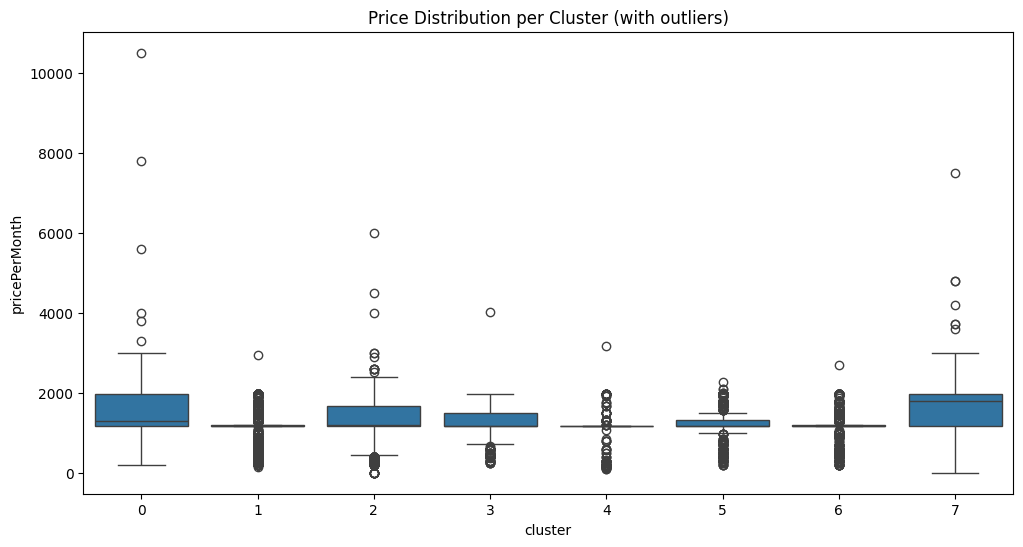

In [14]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data, x="cluster", y="pricePerMonth")
plt.title("Price Distribution per Cluster (with outliers)")
plt.show()

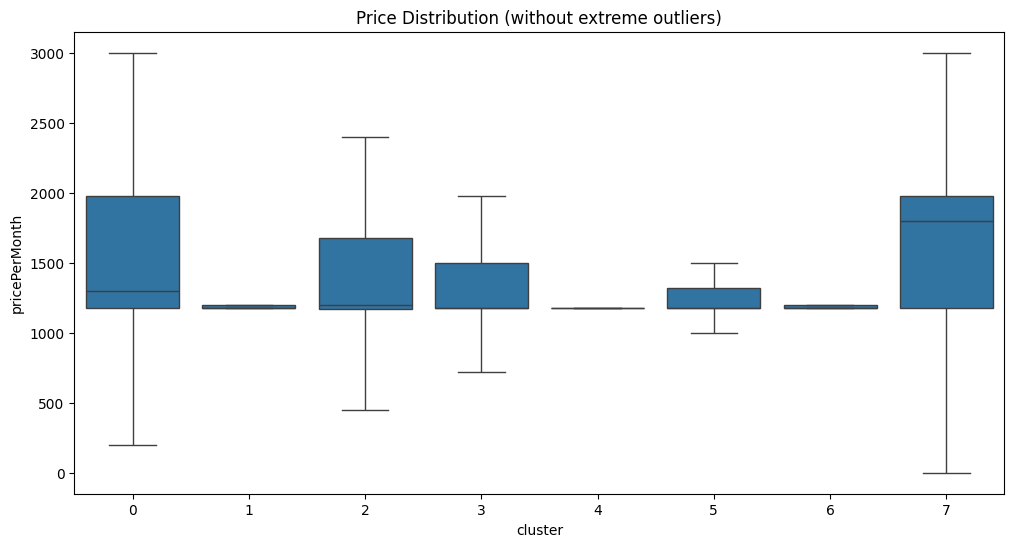

In [15]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data, x="cluster", y="pricePerMonth", showfliers=False)

plt.title("Price Distribution (without extreme outliers)")
plt.show()

## Cluster revenue

In [16]:
rentals = transactions.merge(
    data[["id", "cluster", "pricePerWeek", "pricePerMonth"]],
    left_on="outfit.id",
    right_on="id",
    how="left"
)

Calculate rental duration/period

In [17]:
rentals["duration_days"] = (
    pd.to_datetime(rentals["rentalPeriod.end"]) -
    pd.to_datetime(rentals["rentalPeriod.start"])
).dt.days

In [18]:
rentals["revenue"] = np.where(
    rentals["duration_days"] <= 30,
    # Case A: Shorter/equal 1 month -> weekly price per started week (rounded up)
    # np.ceil(8/7) = 2.0 -> 2 * weekly price
    np.ceil(rentals["duration_days"] / 7) * rentals["pricePerWeek"],

    # Case B: Longer than 1 month -> monthly price for every started month
    # np.ceil(32/30) = 2.0 -> 2 * monthly price
    np.ceil(rentals["duration_days"] / 30) * rentals["pricePerMonth"] # not 100% accurate - i guess they would not charge for the full month if only 1 day is used, but we don't have more detailed data
)


In [19]:
cluster_revenue = rentals.groupby("cluster")["revenue"].agg([
    "sum", "mean", "count"
]).sort_values("sum", ascending=False)

cluster_revenue

,sum,mean,count
cluster,,,
2.0,71299983.0,2617.761978,27237
7.0,28520090.0,3864.510840,7380
1.0,24240702.0,2819.669885,8597
3.0,20881580.0,3174.457282,6578
5.0,11891420.0,3028.889455,3926
6.0,9086105.0,2867.183654,3169
0.0,8436395.0,2841.493769,2969
4.0,2685215.0,2438.887375,1101


## Customer revenue

In [20]:
customer_revenue = rentals.groupby("customer.id")["revenue"].sum()

Customer Cluster Affinity

In [21]:
customer_cluster_revenue = rentals.groupby(
    ["customer.id", "cluster"]
)["revenue"].sum().unstack(fill_value=0)

customer_cluster_revenue.head()

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
customer.id,,,,,,,,
1,0.0,0.0,390.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,960.0,0.0,0.0,0.0,0.0,0.0
3,10890.0,16580.0,48030.0,3960.0,3960.0,15840.0,0.0,20640.0
4,0.0,0.0,870.0,0.0,0.0,0.0,0.0,0.0
5,700.0,0.0,600.0,0.0,0.0,0.0,0.0,0.0


Value Mapping: Cash Cow vs. High End

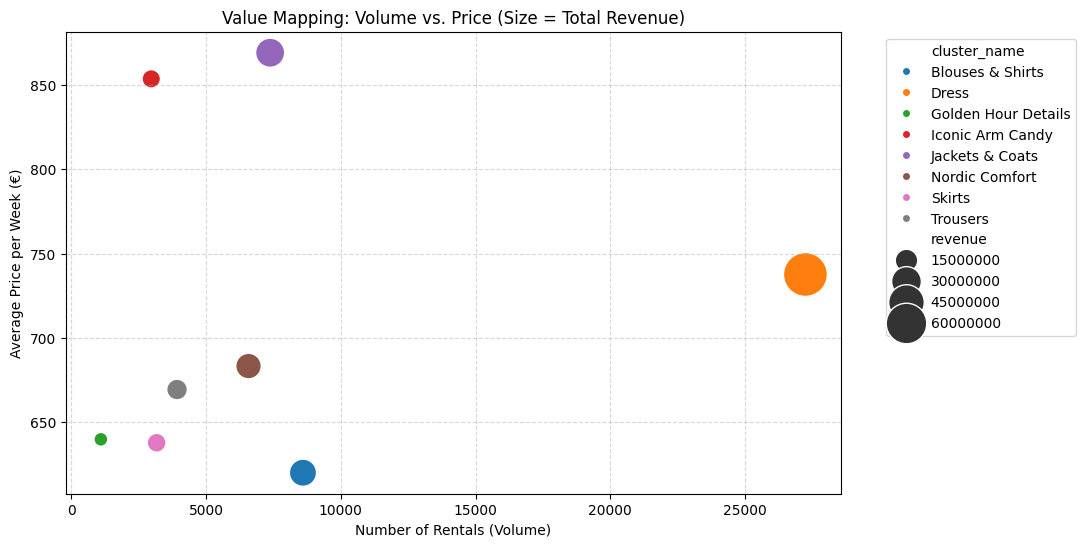

In [23]:
# Aggregate metrics per cluster
cluster_economics = rentals.merge(data[["id", "cluster_name"]], left_on="outfit.id", right_on="id").groupby("cluster_name").agg({
    "revenue": "sum",
    "id_x": "count", # Transaction count
    "pricePerWeek": "mean" # Avg price
}).rename(columns={"id_x": "rental_volume", "pricePerWeek": "avg_price"})

# Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(data=cluster_economics, x="rental_volume", y="avg_price", size="revenue", sizes=(100, 1000), hue=cluster_economics.index)
plt.title("Value Mapping: Volume vs. Price (Size = Total Revenue)")
plt.xlabel("Number of Rentals (Volume)")
plt.ylabel("Average Price per Week (€)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

White Spaces: Utilization - Identifying where demand exceeds supply

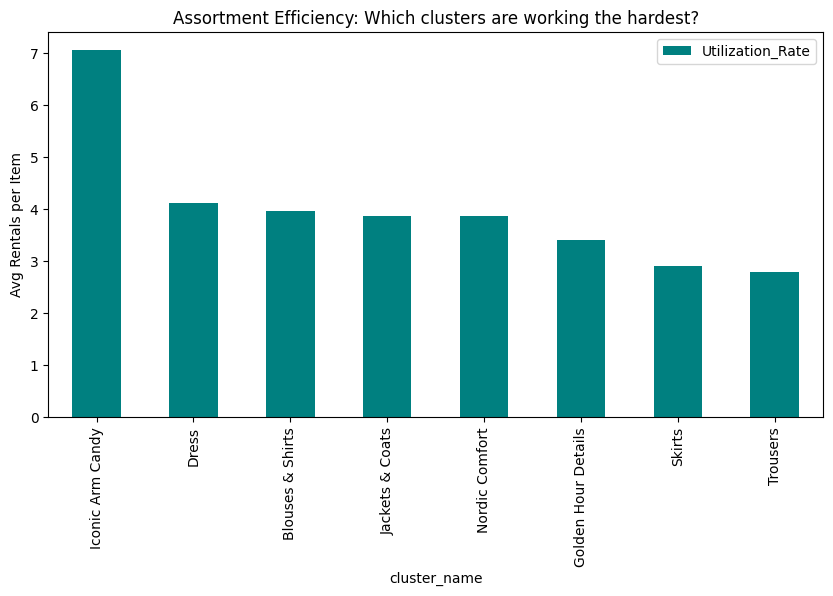

In [24]:
# 1. Count items in inventory per cluster
inventory_count = data.groupby("cluster_name")["id"].count()

# 2. Count rentals per cluster
rental_count = rentals.merge(data, left_on="outfit.id", right_on="id").groupby("cluster_name")["id_x"].count()

# 3. Calculate Utilization (Rentals per Item)
utilization = pd.DataFrame({"Inventory": inventory_count, "Rentals": rental_count})
utilization["Utilization_Rate"] = utilization["Rentals"] / utilization["Inventory"]

# Sort and visualize
utilization.sort_values("Utilization_Rate", ascending=False).plot(kind="bar", y="Utilization_Rate", color="teal", figsize=(10,5))
plt.title("Assortment Efficiency: Which clusters are working the hardest?")
plt.ylabel("Avg Rentals per Item")
plt.show()

In [25]:
utilization.sort_values("Utilization_Rate", ascending=False)

,Inventory,Rentals,Utilization_Rate
cluster_name,,,
Iconic Arm Candy,421,2969,7.052257
Dress,6623,27237,4.112487
Blouses & Shirts,2168,8597,3.965406
Jackets & Coats,1911,7380,3.861852
Nordic Comfort,1704,6578,3.860329
Golden Hour Details,323,1101,3.408669
Skirts,1090,3169,2.907339
Trousers,1409,3926,2.786373


**Results**

Bags are rented out way more per bag than other product categories (near double the catalogue average) --> there is the need to buy more bags (just 421 pieces in inventory)

Core volume driver are dresses with the most inventory and most rentals (and high utilization rate) --> shows inventory size is correct

Trousers and skirts are not heavily utilized --> customers prefer renting special occasion fits over everyday basics

Golden Hour Details are not utilized that much either and have a relatively low revenue (as seen in the plot above) 
